In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [7]:
# load the data
data = pd.read_excel('/DataScinceExlr/Assignments/12. Random Forest/glass.xlsx', sheet_name='glass')

In [8]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [10]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


#### 1. Exploratory Data Analysis (EDA):

In [11]:
data.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

 #### No missing values, no imputation required

In [12]:
data['Type'].value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [13]:
'''
Certain glass categories contain substantially fewer observations, highlighting an imbalance in class distribution.
'''

'\nCertain glass categories contain substantially fewer observations, highlighting an imbalance in class distribution.\n'

#### 2: Data Visualization:

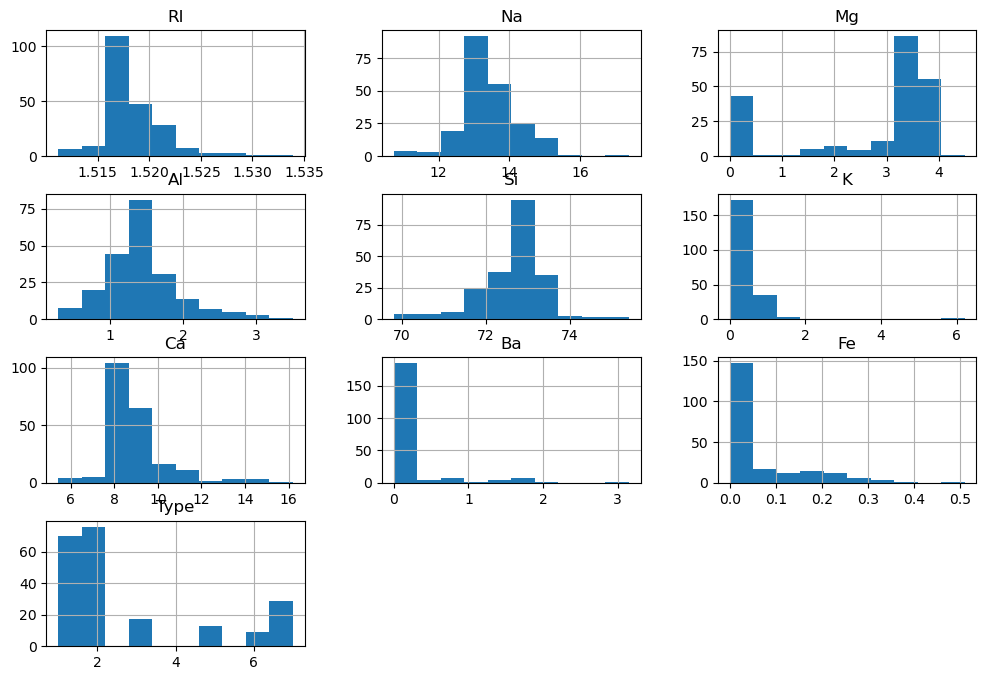

In [14]:
data.hist(figsize=(12,8))
plt.show()


#### The features have different value ranges and exhibit some skewness; therefore, feature scaling is required.

<Figure size 600x400 with 0 Axes>

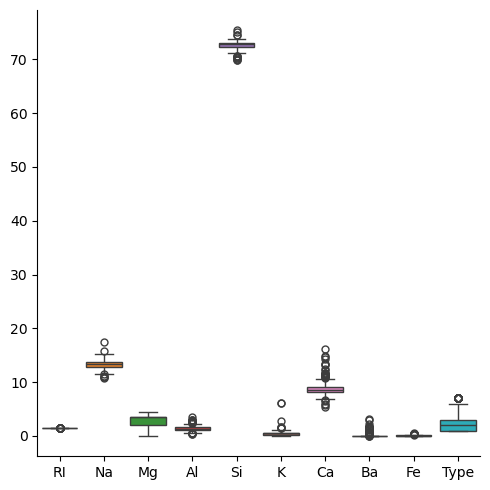

In [15]:
plt.figure(figsize=(6, 4))
sns.catplot(data, kind='box')
plt.show()

#### Outliers are present in some chemical components; however, Random Forest is robust to outliers, so removal is not required.

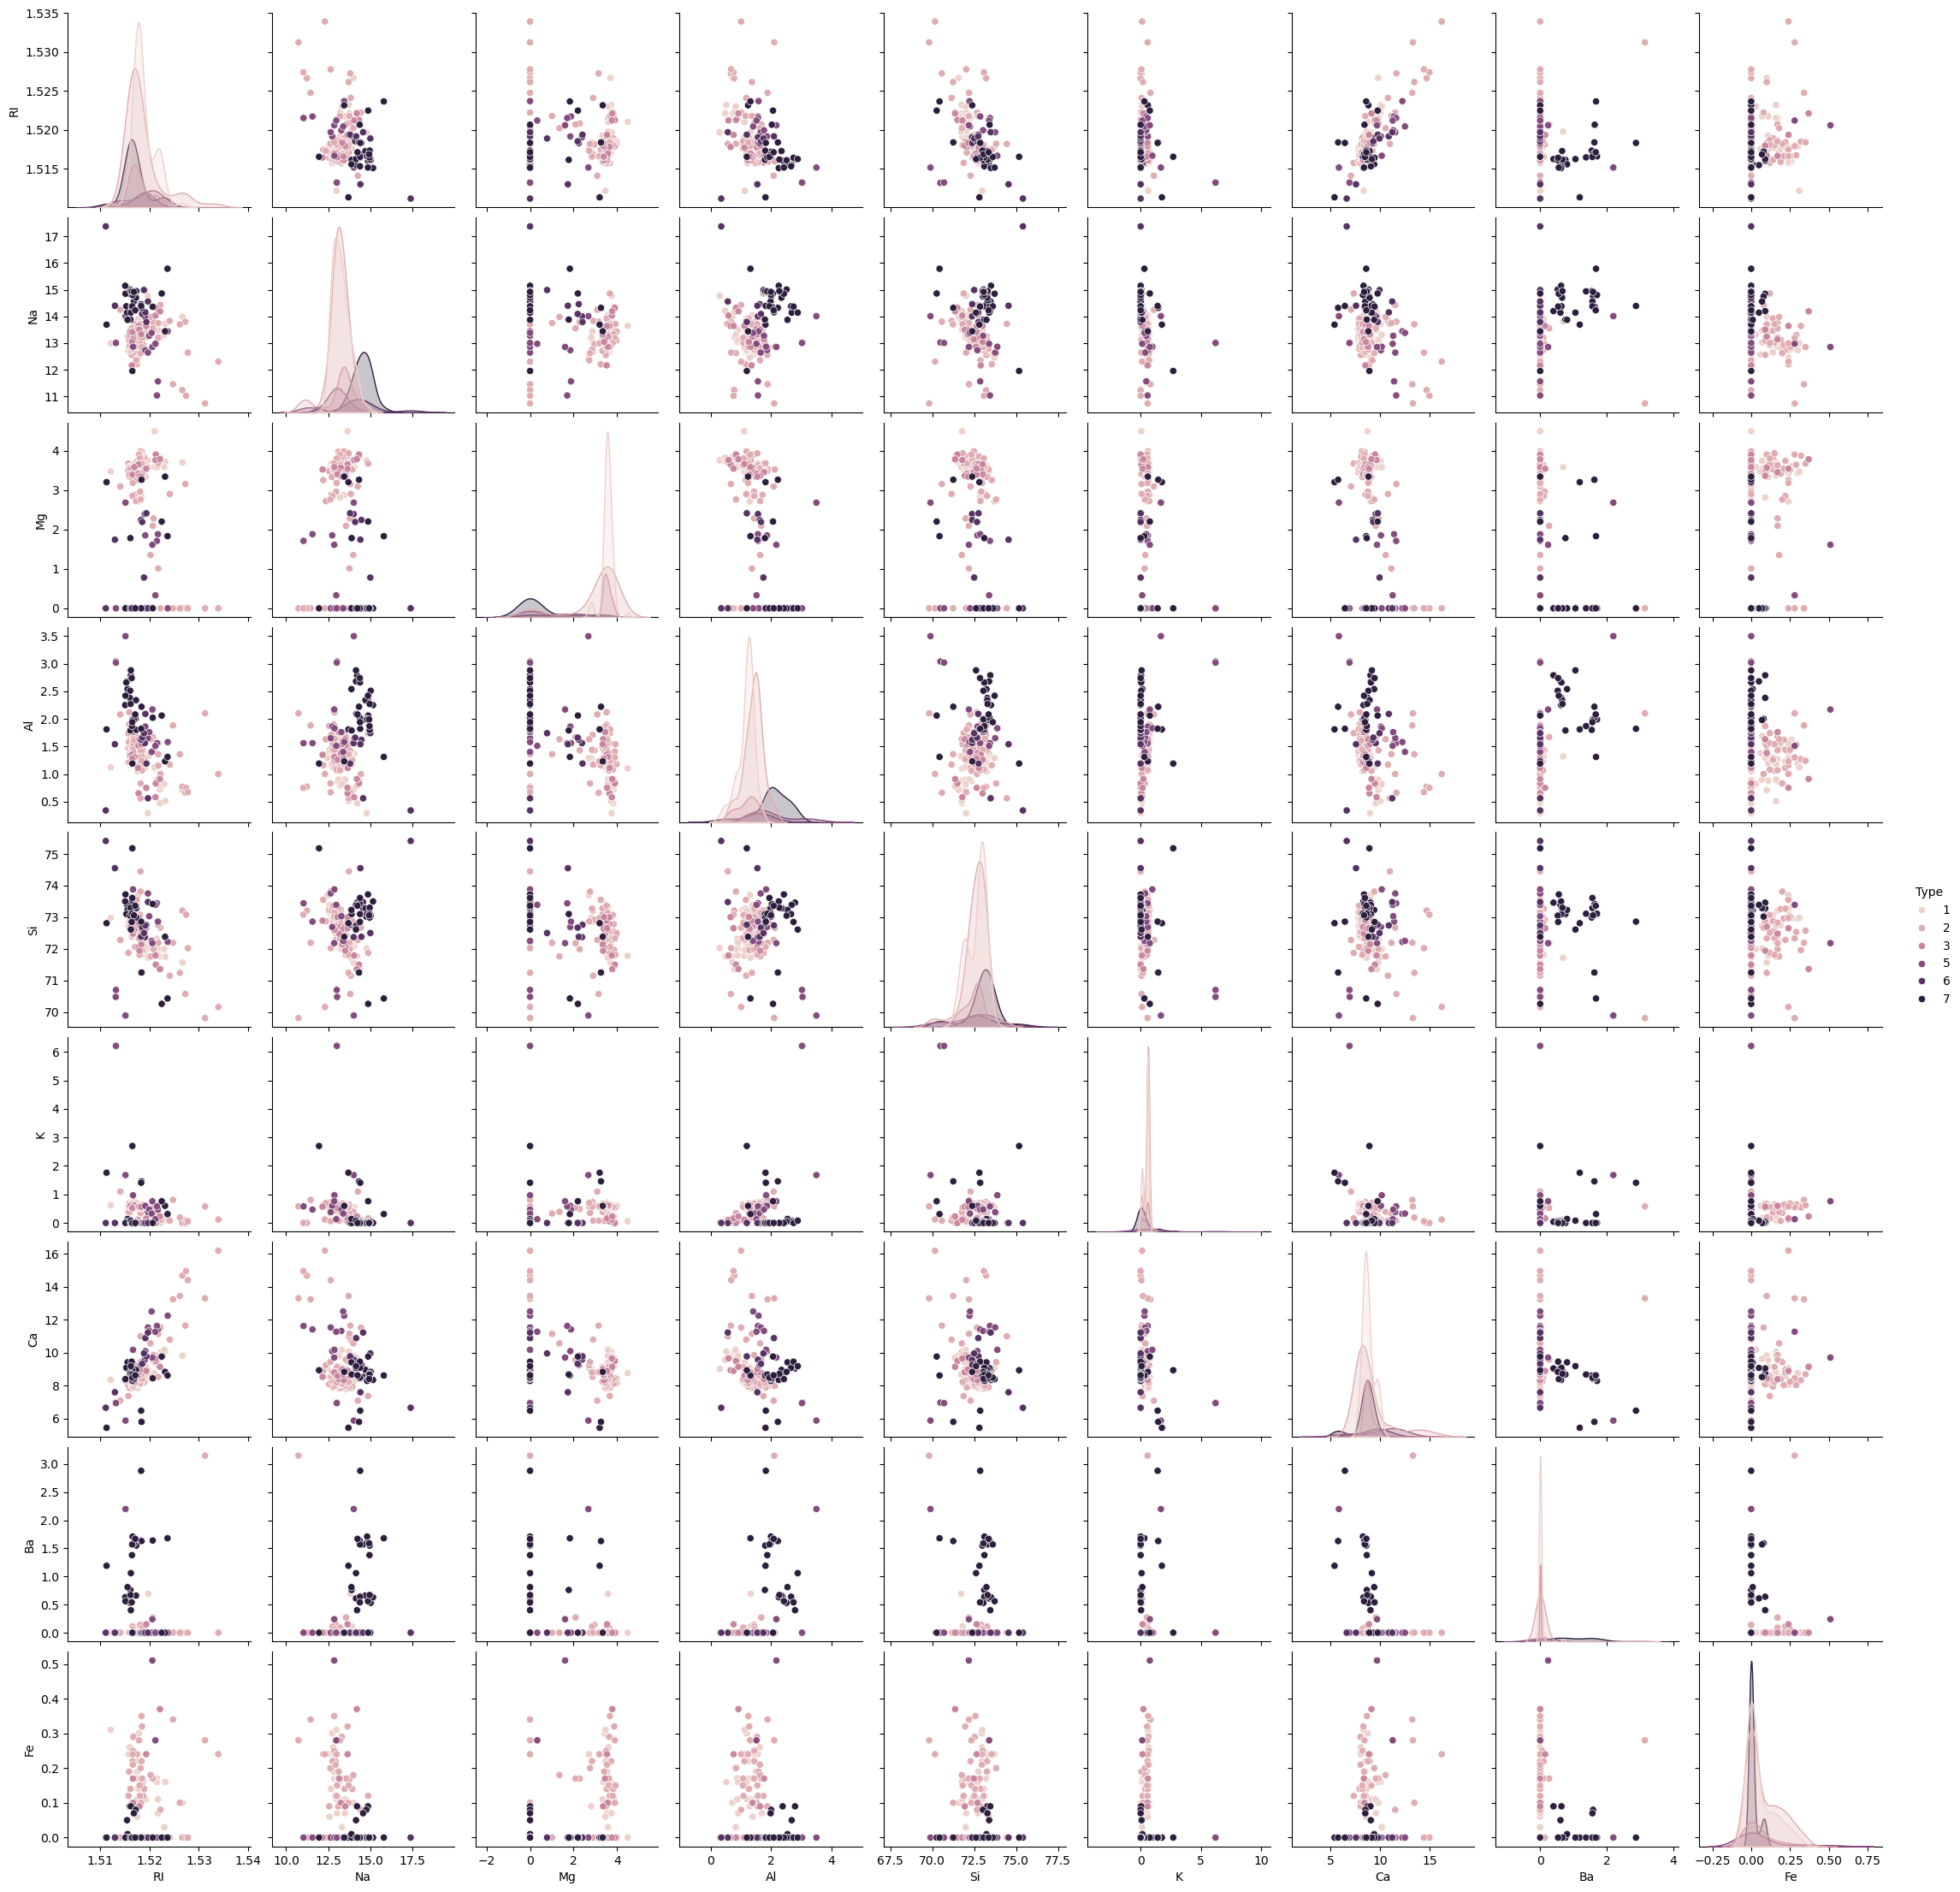

In [16]:
sns.pairplot(data, hue='Type', diag_kind='kde')
plt.show()

#### The observed partial class separation suggests non-linear patterns in the data, making tree-based models an appropriate choice.

#### 3: Data Preprocessing

In [17]:
'''
The dataset is complete with no missing values, so no preprocessing for imputation is needed. 
It also contains only numerical features, eliminating the need for categorical encoding.
'''

'\nThe dataset is complete with no missing values, so no preprocessing for imputation is needed. \nIt also contains only numerical features, eliminating the need for categorical encoding.\n'

In [18]:
# Split the dataset into predictor variables (X) and the target variable (y)

X = data.drop('Type', axis=1)
y = data['Type']

In [19]:
# Perform feature scaling using StandardScaler to ensure
# that all input variables are on a similar scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Although Random Forest does not require feature scaling, it is applied here to ensure a fair comparison with boosting models.

In [20]:
# Apply SMOTE to address class imbalance by creating synthetic samples
# for underrepresented classes, thereby improving model fairness and performance.

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resmpl, y_resmpl = smote.fit_resample(X_scaled, y)

  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [21]:
# Divide the balanced dataset into training and testing subsets
# using stratified sampling to preserve class proportions

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resmpl, y_resmpl,
    test_size=0.2,
    random_state=42,
    stratify=y_resmpl
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((364, 9), (92, 9), (364,), (92,))

#### 4. Implementation of the Random Forest Classification Model

In [22]:
# Build the Random Forest model with 500 trees and a maximum depth of 6
# Then train the model using the training dataset

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=500, random_state=42)

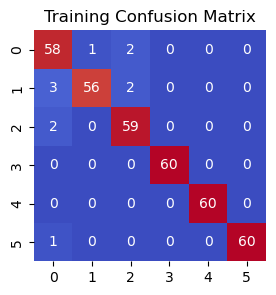

Training Classification Report:

              precision    recall  f1-score   support

           1       0.91      0.95      0.93        61
           2       0.98      0.92      0.95        61
           3       0.94      0.97      0.95        61
           5       1.00      1.00      1.00        60
           6       1.00      1.00      1.00        60
           7       1.00      0.98      0.99        61

    accuracy                           0.97       364
   macro avg       0.97      0.97      0.97       364
weighted avg       0.97      0.97      0.97       364



In [23]:
# Assess model performance on the training set using confusion matrix
# and classification metrics to check for potential overfitting

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

yhat_train = rf.predict(X_train)

plt.figure(figsize=(3, 3))
cm = confusion_matrix(y_train, yhat_train)
sns.heatmap(cm, cmap='coolwarm', cbar=False, annot=True, fmt='d')
plt.title("Training Confusion Matrix")
plt.show()

print("Training Classification Report:\n")
print(classification_report(y_train, yhat_train))

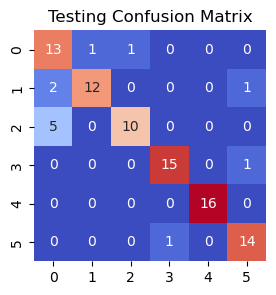

              precision    recall  f1-score   support

           1       0.65      0.87      0.74        15
           2       0.92      0.80      0.86        15
           3       0.91      0.67      0.77        15
           5       0.94      0.94      0.94        16
           6       1.00      1.00      1.00        16
           7       0.88      0.93      0.90        15

    accuracy                           0.87        92
   macro avg       0.88      0.87      0.87        92
weighted avg       0.88      0.87      0.87        92



In [24]:
# Assess model generalization performance on the test dataset
# using confusion matrix and classification metrics

yhat_test = rf.predict(X_test)

plt.figure(figsize=(3, 3))
cm = confusion_matrix(y_test, yhat_test)
sns.heatmap(cm, cmap='coolwarm', cbar=False, annot=True, fmt='d')
plt.title("Testing Confusion Matrix")
plt.show()

print(classification_report(y_test, yhat_test))

### Precision and recall are well-balanced across all classes, suggesting consistent classification performance.

#### 5: Bagging and Boosting Methods

#### Bagging Method

In [26]:
# Apply Bagging with a shallow Decision Tree (max_depth=1) as the weak learner
# and train the ensemble model on the training dataset

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    random_state=42
)

bagging.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                  n_estimators=200, random_state=42)

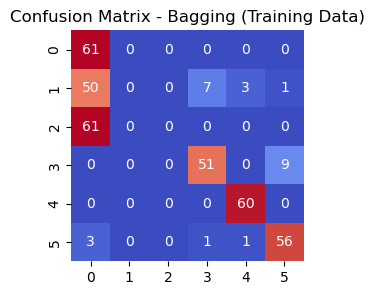

Training Classification Report:

              precision    recall  f1-score   support

           1       0.35      1.00      0.52        61
           2       0.00      0.00      0.00        61
           3       0.00      0.00      0.00        61
           5       0.86      0.85      0.86        60
           6       0.94      1.00      0.97        60
           7       0.85      0.92      0.88        61

    accuracy                           0.63       364
   macro avg       0.50      0.63      0.54       364
weighted avg       0.50      0.63      0.54       364



In [27]:
# Evaluate the Bagging model on the training dataset

yhat_train = bagging.predict(X_train)

# Plot the confusion matrix
plt.figure(figsize=(3, 3))
cm = confusion_matrix(y_train, yhat_train)
sns.heatmap(cm, cmap='coolwarm', cbar=False, annot=True, fmt='d')
plt.title("Confusion Matrix - Bagging (Training Data)")
plt.show()

# Display classification metrics
print("Training Classification Report:\n")
print(classification_report(y_train, yhat_train))

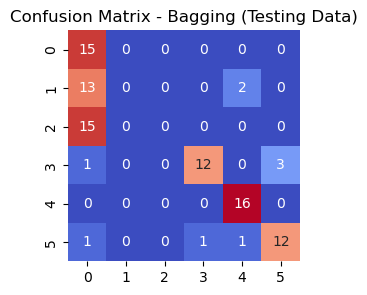

Testing Classification Report:

              precision    recall  f1-score   support

           1       0.33      1.00      0.50        15
           2       0.00      0.00      0.00        15
           3       0.00      0.00      0.00        15
           5       0.92      0.75      0.83        16
           6       0.84      1.00      0.91        16
           7       0.80      0.80      0.80        15

    accuracy                           0.60        92
   macro avg       0.48      0.59      0.51        92
weighted avg       0.49      0.60      0.51        92



In [28]:
# Evaluate the Bagging model on the testing dataset

yhat_test = bagging.predict(X_test)

# Plot the confusion matrix
plt.figure(figsize=(3, 3))
cm = confusion_matrix(y_test, yhat_test)
sns.heatmap(cm, cmap='coolwarm', cbar=False, annot=True, fmt='d')
plt.title("Confusion Matrix - Bagging (Testing Data)")
plt.show()

# Display classification metrics
print("Testing Classification Report:\n")
print(classification_report(y_test, yhat_test))

#### Boosting(AdaBoost)

In [29]:
# Apply the AdaBoost algorithm with 200 weak learners
# and train the boosting model on the training dataset

from sklearn.ensemble import AdaBoostClassifier

boosting = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

boosting.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=200, random_state=42)

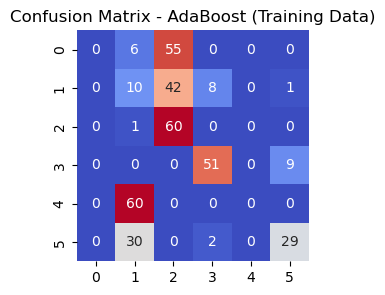

Training Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        61
           2       0.09      0.16      0.12        61
           3       0.38      0.98      0.55        61
           5       0.84      0.85      0.84        60
           6       0.00      0.00      0.00        60
           7       0.74      0.48      0.58        61

    accuracy                           0.41       364
   macro avg       0.34      0.41      0.35       364
weighted avg       0.34      0.41      0.35       364



In [30]:
# Evaluate the AdaBoost model on the training dataset

yhat_train = boosting.predict(X_train)

# Plot the confusion matrix
plt.figure(figsize=(3, 3))
cm = confusion_matrix(y_train, yhat_train)
sns.heatmap(cm, cmap='coolwarm', cbar=False, annot=True, fmt='d')
plt.title("Confusion Matrix - AdaBoost (Training Data)")
plt.show()

# Display classification metrics
print("Training Classification Report:\n")
print(classification_report(y_train, yhat_train))

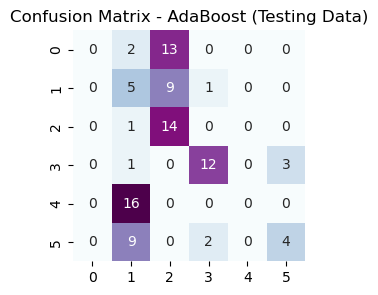

Testing Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        15
           2       0.15      0.33      0.20        15
           3       0.39      0.93      0.55        15
           5       0.80      0.75      0.77        16
           6       0.00      0.00      0.00        16
           7       0.57      0.27      0.36        15

    accuracy                           0.38        92
   macro avg       0.32      0.38      0.32        92
weighted avg       0.32      0.38      0.32        92



In [31]:
# Evaluate the AdaBoost model on the testing dataset

yhat_test = boosting.predict(X_test)

# Plot the confusion matrix
plt.figure(figsize=(3, 3))
cm = confusion_matrix(y_test, yhat_test)
sns.heatmap(cm, cmap='BuPu', cbar=False, annot=True, fmt='d')
plt.title("Confusion Matrix - AdaBoost (Testing Data)")
plt.show()

# Display classification metrics
print("Testing Classification Report:\n")
print(classification_report(y_test, yhat_test))

#### Ada boost with different parameters

In [32]:
# Implement AdaBoost using a shallow Decision Tree (decision stump)
# Set the number of estimators to 200 and control the contribution
# of each learner using a learning rate of 0.5

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

In [33]:
ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=200, random_state=42)

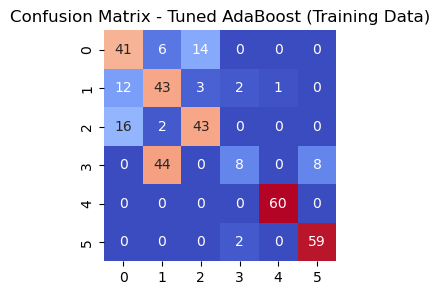

Training Classification Report:

              precision    recall  f1-score   support

           1       0.59      0.67      0.63        61
           2       0.45      0.70      0.55        61
           3       0.72      0.70      0.71        61
           5       0.67      0.13      0.22        60
           6       0.98      1.00      0.99        60
           7       0.88      0.97      0.92        61

    accuracy                           0.70       364
   macro avg       0.72      0.70      0.67       364
weighted avg       0.72      0.70      0.67       364



In [34]:
# Evaluate the tuned AdaBoost model on the training dataset

yhat_train = ada.predict(X_train)

# Plot the confusion matrix
plt.figure(figsize=(3, 3))
cm = confusion_matrix(y_train, yhat_train)
sns.heatmap(cm, cmap='coolwarm', cbar=False, annot=True, fmt='d')
plt.title("Confusion Matrix - Tuned AdaBoost (Training Data)")
plt.show()

# Display classification metrics
print("Training Classification Report:\n")
print(classification_report(y_train, yhat_train))

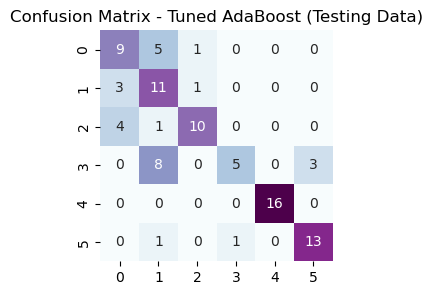

Testing Classification Report:

              precision    recall  f1-score   support

           1       0.56      0.60      0.58        15
           2       0.42      0.73      0.54        15
           3       0.83      0.67      0.74        15
           5       0.83      0.31      0.45        16
           6       1.00      1.00      1.00        16
           7       0.81      0.87      0.84        15

    accuracy                           0.70        92
   macro avg       0.74      0.70      0.69        92
weighted avg       0.75      0.70      0.69        92



In [35]:
# Evaluate the tuned AdaBoost model on the testing dataset

yhat_test = ada.predict(X_test)

# Plot the confusion matrix
plt.figure(figsize=(3, 3))
cm = confusion_matrix(y_test, yhat_test)
sns.heatmap(cm, cmap='BuPu', cbar=False, annot=True, fmt='d')
plt.title("Confusion Matrix - Tuned AdaBoost (Testing Data)")
plt.show()

# Display classification metrics
print("Testing Classification Report:\n")
print(classification_report(y_test, yhat_test))

#### Overall, Random Forest proved to be the most effective model due to its stability, predictive accuracy, and robustness.

#### Bagging vs Boosting

- Bagging trains multiple models in parallel using bootstrap samples. It primarily reduces variance and helps prevent overfitting by averaging predictions across models.

- Boosting trains models sequentially, where each new model focuses on correcting the errors of the previous one. It mainly reduces bias but may lead to overfitting if not properly tuned.

#### Techniques to Handle Imbalanced Data

Several techniques were applied or considered to address class imbalance:

- SMOTE (Synthetic Minority Oversampling Technique): Generates synthetic samples for minority classes to balance the dataset.

- Stratified Splitting: Ensures that class proportions are maintained in both training and testing datasets.

- Ensemble Methods: Improve predictive performance and reduce bias toward majority classes.

Class Weighting: Assigns higher importance to minority classes during model training.

Evaluation Using F1-Score Instead of Accuracy: Provides a balanced metric that considers both precision and recall, which is more appropriate for imbalanced datasets.